In [1]:
import pandas as pd
from pathlib import Path

In [32]:
datasets_dir = Path('datasets')

In [3]:


excel_files = [
    'aihw-can-122-CDiA-2023-Book-1a-Cancer-incidence-age-standardised-rates-5-year-age-groups.xlsx',
    'aihw-can-122-CDiA-2023-Book-2a-Cancer-mortality-and-age-standardised-rates-by-age-5-year-groups.xlsx',
    'aihw-can-122-CDiA-2023-Book-7-Cancer-incidence-by-state-and-territory.xlsx',
]

for filename in excel_files:
    xlsx_path = datasets_dir / filename
    xf = pd.ExcelFile(xlsx_path)
    sheet_name = xf.sheet_names[1]  # second worksheet (index 1)
    df = pd.read_excel(xlsx_path, sheet_name=1)
    csv_path = datasets_dir / (Path(filename).stem + '.csv')
    df.to_csv(csv_path, index=False)
    print(f'{filename}')
    print(f'  Sheet: "{sheet_name}" | Shape: {df.shape}')
    print(f'  Saved -> {csv_path}\n')

aihw-can-122-CDiA-2023-Book-1a-Cancer-incidence-age-standardised-rates-5-year-age-groups.xlsx
  Sheet: "Table S1a.1" | Shape: (227405, 13)
  Saved -> datasets/aihw-can-122-CDiA-2023-Book-1a-Cancer-incidence-age-standardised-rates-5-year-age-groups.csv



aihw-can-122-CDiA-2023-Book-2a-Cancer-mortality-and-age-standardised-rates-by-age-5-year-groups.xlsx
  Sheet: "Table S2a.1" | Shape: (261203, 13)
  Saved -> datasets/aihw-can-122-CDiA-2023-Book-2a-Cancer-mortality-and-age-standardised-rates-by-age-5-year-groups.csv



aihw-can-122-CDiA-2023-Book-7-Cancer-incidence-by-state-and-territory.xlsx
  Sheet: "Table S7.1" | Shape: (69466, 10)
  Saved -> datasets/aihw-can-122-CDiA-2023-Book-7-Cancer-incidence-by-state-and-territory.csv



## Load CSVs

In [33]:
NA_VALUES = ['. .', 'n.p.', 'N/A', 'na', '']

# Book 1a — Cancer incidence by age group
df_incidence = pd.read_csv(
    datasets_dir / 'aihw-can-122-CDiA-2023-Book-1a-Cancer-incidence-age-standardised-rates-5-year-age-groups.csv',
    skiprows=5,
    na_values=NA_VALUES
)
df_incidence.columns = df_incidence.columns.str.strip()
# Drop fully empty trailing columns
df_incidence = df_incidence.dropna(axis=1, how='all')

print('df_incidence shape:', df_incidence.shape)
df_incidence.head()

df_incidence shape: (227400, 13)


,Data type,Cancer group/site,Year,Sex,Age group (years),Count,"Age-specific rate\n(per 100,000)","Age-standardised rate\n2001 Australian Standard Population (per 100,000)","Age-standardised rate\n2023 Australian population \n(per 100,000)","Age-standardised rate\n (WHO) (per 100,000)","Age-standardised rate\n (Segi) (per 100,000)",Unnamed: 11,ICD10 codes
0,Actual,Acute lymphoblastic leukaemia,1982.0,Males,00–04,42.0,7.1,NaN,NaN,NaN,NaN,,C91.0
1,Actual,Acute lymphoblastic leukaemia,1982.0,Males,05–09,25.0,4.0,NaN,NaN,NaN,NaN,,C91.0
2,Actual,Acute lymphoblastic leukaemia,1982.0,Males,10–14,14.0,2.0,NaN,NaN,NaN,NaN,,C91.0
3,Actual,Acute lymphoblastic leukaemia,1982.0,Males,15–19,14.0,2.1,NaN,NaN,NaN,NaN,,C91.0
4,Actual,Acute lymphoblastic leukaemia,1982.0,Males,20–24,5.0,0.7,NaN,NaN,NaN,NaN,,C91.0


In [34]:
# Book 2a — Cancer mortality by age group
df_mortality = pd.read_csv(
    datasets_dir / 'aihw-can-122-CDiA-2023-Book-2a-Cancer-mortality-and-age-standardised-rates-by-age-5-year-groups.csv',
    skiprows=5,
    na_values=NA_VALUES
)
df_mortality.columns = df_mortality.columns.str.strip()
df_mortality = df_mortality.dropna(axis=1, how='all')

print('df_mortality shape:', df_mortality.shape)
df_mortality.head()

df_mortality shape: (261198, 13)


,Data type,Cancer group/site,Year,Sex,Age group (years),Count,"Age-specific rate\n(per 100,000)","Age-standardised rate\n2001 Australian Standard Population (per 100,000)","Age-standardised rate\n2023 Australian population \n(per 100,000)","Age-standardised rate\n (WHO) (per 100,000)","Age-standardised rate\n (Segi) (per 100,000)",Unnamed: 11,ICD10 codes
0,Actual,Acute lymphoblastic leukaemia,1971.0,Males,00–04,21.0,3.3,NaN,NaN,NaN,NaN,,C91.0
1,Actual,Acute lymphoblastic leukaemia,1971.0,Males,05–09,24.0,3.8,NaN,NaN,NaN,NaN,,C91.0
2,Actual,Acute lymphoblastic leukaemia,1971.0,Males,10–14,11.0,1.7,NaN,NaN,NaN,NaN,,C91.0
3,Actual,Acute lymphoblastic leukaemia,1971.0,Males,15–19,2.0,0.3,NaN,NaN,NaN,NaN,,C91.0
4,Actual,Acute lymphoblastic leukaemia,1971.0,Males,20–24,3.0,0.5,NaN,NaN,NaN,NaN,,C91.0


In [35]:
# Book 7 — Cancer incidence by state and territory
df_state = pd.read_csv(
    datasets_dir / 'aihw-can-122-CDiA-2023-Book-7-Cancer-incidence-by-state-and-territory.csv',
    skiprows=5,
    na_values=NA_VALUES
)
df_state.columns = df_state.columns.str.strip()
df_state = df_state.dropna(axis=1, how='all')

print('df_state shape:', df_state.shape)
df_state.head()

df_state shape: (69461, 10)


,Data type,Cancer group/site,Year,Sex,State or Territory,Count,"Age-standardised rate\n2001 Australian Standard Population \n(per 100,000)","Age-standardised rate\n2023 Australian population \n(per 100,000)",Unnamed: 8,ICD-10 codes
0,Incidence,Acute lymphoblastic leukaemia,1982.0,Males,New South Wales,54.0,1.9,1.8,,C91.0
1,Incidence,Acute lymphoblastic leukaemia,1982.0,Males,Victoria,31.0,1.4,1.4,,C91.0
2,Incidence,Acute lymphoblastic leukaemia,1982.0,Males,Queensland,20.0,1.4,1.3,,C91.0
3,Incidence,Acute lymphoblastic leukaemia,1982.0,Males,Western Australia,4.0,NaN,NaN,,C91.0
4,Incidence,Acute lymphoblastic leukaemia,1982.0,Males,South Australia,17.0,2.4,2.5,,C91.0


## Inspect & Clean

In [36]:
for name, df in [('incidence', df_incidence), ('mortality', df_mortality), ('state', df_state)]:
    print(f'=== df_{name} ===')
    df.info()
    print(f'Null counts:\n{df.isnull().sum()}\n')

=== df_incidence ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227400 entries, 0 to 227399
Data columns (total 13 columns):
 #   Column                                                                   Non-Null Count   Dtype  
---  ------                                                                   --------------   -----  
 0   Data type                                                                227397 non-null  object 
 1   Cancer group/site                                                        227380 non-null  object 
 2   Year                                                                     227380 non-null  float64
 3   Sex                                                                      227380 non-null  object 
 4   Age group (years)                                                        227380 non-null  object 
 5   Count                                                                    227380 non-null  float64
 6   Age-specific rate
(per 100,000)        

In [37]:
# Standardise column names (lowercase, underscores)
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.lower()
        .str.replace(r'\s+', '_', regex=True)
        .str.replace(r'[^\w]', '_', regex=True)
        .str.strip('_')
    )
    return df

df_incidence = clean_columns(df_incidence)
df_mortality = clean_columns(df_mortality)
df_state     = clean_columns(df_state)

# Convert Count to numeric (coerce any stray strings to NaN)
for df in [df_incidence, df_mortality, df_state]:
    df['count'] = pd.to_numeric(df['count'], errors='coerce')
    df['year']  = pd.to_numeric(df['year'],  errors='coerce')

print('Columns — incidence:', df_incidence.columns.tolist())
print('Columns — mortality:', df_mortality.columns.tolist())
print('Columns — state:',    df_state.columns.tolist())

Columns — incidence: ['data_type', 'cancer_group_site', 'year', 'sex', 'age_group__years', 'count', 'age_specific_rate__per_100_000', 'age_standardised_rate_2001_australian_standard_population__per_100_000', 'age_standardised_rate_2023_australian_population__per_100_000', 'age_standardised_rate__who___per_100_000', 'age_standardised_rate__segi___per_100_000', 'unnamed__11', 'icd10_codes']
Columns — mortality: ['data_type', 'cancer_group_site', 'year', 'sex', 'age_group__years', 'count', 'age_specific_rate__per_100_000', 'age_standardised_rate_2001_australian_standard_population__per_100_000', 'age_standardised_rate_2023_australian_population__per_100_000', 'age_standardised_rate__who___per_100_000', 'age_standardised_rate__segi___per_100_000', 'unnamed__11', 'icd10_codes']
Columns — state: ['data_type', 'cancer_group_site', 'year', 'sex', 'state_or_territory', 'count', 'age_standardised_rate_2001_australian_standard_population__per_100_000', 'age_standardised_rate_2023_australian_popul

In [38]:
df_incidence.groupby('cancer_group_site').agg({'count': 'sum'}).sort_values('count', ascending=False).head(10)

,count
cancer_group_site,
All cancers combined,16694784.0
Prostate cancer,2393362.0
Breast cancer,2068896.0
Colorectal cancer,2060060.0
Melanoma of the skin,1665028.0
Lung cancer,1582892.0
Colon cancer,1380562.0
All blood cancers combined,1210200.0
Gynaecological cancers,746180.0


In [39]:
df_incidence['cancer_group_site'] = df_incidence['cancer_group_site'].str.lower()
df_mortality['cancer_group_site'] = df_mortality['cancer_group_site'].str.lower()

Filtering to just 'Melanoma of the skin'

In [40]:
df_incidence_melanoma = df_incidence[df_incidence['cancer_group_site'] == 'melanoma of the skin']
df_mortality_melanoma = df_mortality[df_mortality['cancer_group_site'] == 'melanoma of the skin']

print('df_incidence_melanoma shape:', df_incidence_melanoma.shape)
print('df_mortality_melanoma shape:', df_mortality_melanoma.shape)

df_incidence_melanoma shape: (2520, 13)
df_mortality_melanoma shape: (3180, 13)


## Visualisations — Incidence & Mortality Rates Over Time

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RATE_COL = 'age_standardised_rate_2001_australian_standard_population__per_100_000'

# Isolate summary (all-ages) rows — age-standardised rate is only populated there
inc_asr  = df_incidence_melanoma.dropna(subset=[RATE_COL])
mort_asr = df_mortality_melanoma.dropna(subset=[RATE_COL])

print('Unique cancer groups in incidence ASR rows:', sorted(inc_asr['cancer_group_site'].unique()))
print('Unique data types:', sorted(inc_asr['data_type'].unique()))

Unique cancer groups in incidence ASR rows: ['melanoma of the skin']
Unique data types: ['Actual', 'Projections']


In [42]:
SEXES  = ['Males', 'Females', 'Persons']
COLORS = {'Males': '#2196F3', 'Females': '#E91E63', 'Persons': '#4CAF50'}

# Data is already filtered to melanoma — just filter on actual data and sex
def get_trend(df, data_type='Actual'):
    mask = (df['data_type'] == data_type) & (df['sex'].isin(SEXES))
    return (
        df.loc[mask, ['year', 'sex', RATE_COL]]
        .dropna()
        .sort_values('year')
    )

inc_trend  = get_trend(inc_asr)
mort_trend = get_trend(mort_asr)

print('Incidence years:', int(inc_trend['year'].min()), '–', int(inc_trend['year'].max()))
print('Mortality years:', int(mort_trend['year'].min()), '–', int(mort_trend['year'].max()))

Incidence years: 1982 – 2019
Mortality years: 1971 – 2021


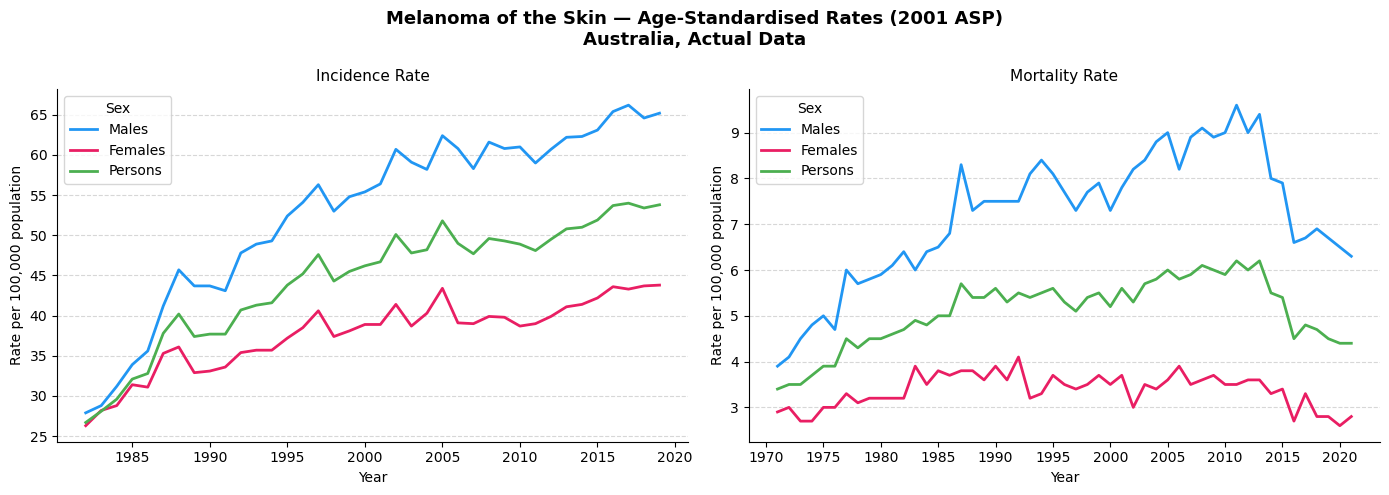

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('Melanoma of the Skin — Age-Standardised Rates (2001 ASP)\nAustralia, Actual Data', fontsize=13, fontweight='bold')

for ax, (trend, title) in zip(axes, [(inc_trend, 'Incidence Rate'), (mort_trend, 'Mortality Rate')]):
    for sex in SEXES:
        subset = trend[trend['sex'] == sex]
        ax.plot(subset['year'], subset[RATE_COL], label=sex, color=COLORS[sex], linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Rate per 100,000 population')
    ax.legend(title='Sex')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('melanoma_incidence_mortality_rates.png', dpi=150, bbox_inches='tight')
plt.show()

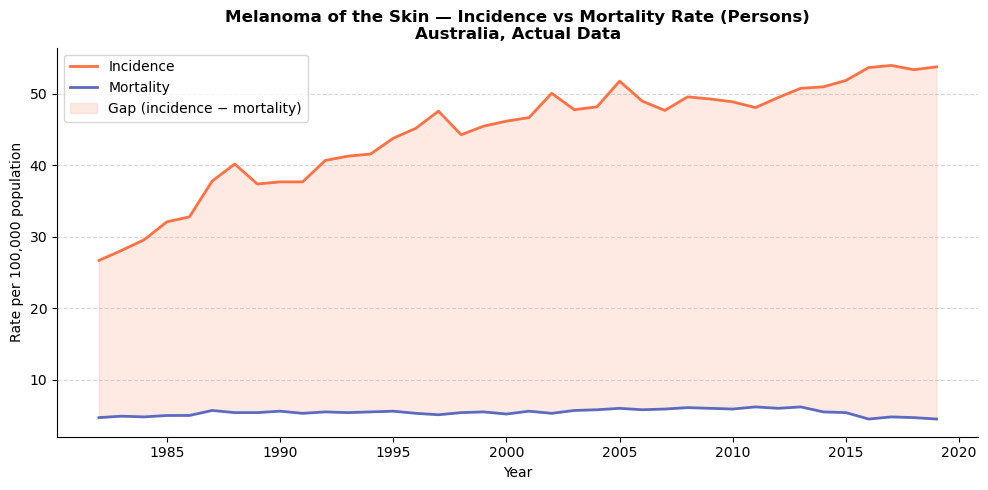

In [44]:
# Incidence vs Mortality on a single chart (Persons only) to show the gap
inc_persons  = inc_trend[inc_trend['sex'] == 'Persons'].set_index('year')
mort_persons = mort_trend[mort_trend['sex'] == 'Persons'].set_index('year')

# Align on common years
common_years = inc_persons.index.intersection(mort_persons.index)
inc_vals  = inc_persons.loc[common_years, RATE_COL]
mort_vals = mort_persons.loc[common_years, RATE_COL]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(common_years, inc_vals,  label='Incidence', color='#FF7043', linewidth=2)
ax.plot(common_years, mort_vals, label='Mortality',  color='#5C6BC0', linewidth=2)
ax.fill_between(common_years, mort_vals, inc_vals, alpha=0.15, color='#FF7043', label='Gap (incidence − mortality)')

ax.set_title('Melanoma of the Skin — Incidence vs Mortality Rate (Persons)\nAustralia, Actual Data', fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Rate per 100,000 population')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('melanoma_incidence_vs_mortality.png', dpi=150, bbox_inches='tight')
plt.show()

## Export data for D3 visualisation

In [45]:
import json

OUT_DIR = Path('../client/public/data')
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEXES_EXPORT    = ['Males', 'Females', 'Persons']
YOUNG_AGE_GROUPS = ['15–19', '20–24', '25–29']
RATE_COL_SPECIFIC = 'age_specific_rate__per_100_000'

def build_young_trend(df, data_type='Actual'):
    """
    Filter to young adult age groups (15–29), average age-specific rates
    per year and sex, then pivot to wide format.
    """
    mask = (
        (df['data_type'] == data_type) &
        (df['age_group__years'].isin(YOUNG_AGE_GROUPS)) &
        (df['sex'].isin(SEXES_EXPORT))
    )
    agg = (
        df.loc[mask, ['year', 'sex', RATE_COL_SPECIFIC]]
        .dropna()
        .groupby(['year', 'sex'])[RATE_COL_SPECIFIC]
        .mean()
        .round(2)
        .reset_index()
    )
    pivot = (
        agg.pivot(index='year', columns='sex', values=RATE_COL_SPECIFIC)
        .reset_index()
    )
    pivot['year'] = pivot['year'].astype(int)
    for col in SEXES_EXPORT:
        if col in pivot.columns:
            pivot[col] = pivot[col].round(2)
    return pivot.to_dict(orient='records')

payload = {
    'incidence': build_young_trend(df_incidence_melanoma),
    'mortality': build_young_trend(df_mortality_melanoma),
}

out_path = OUT_DIR / 'melanoma_rates.json'
with open(out_path, 'w') as f:
    json.dump(payload, f)

print(f'Exported {len(payload["incidence"])} incidence rows and {len(payload["mortality"])} mortality rows')
print(f'Age groups: {YOUNG_AGE_GROUPS}')
print(f'Saved to {out_path.resolve()}')
pd.DataFrame(payload['incidence']).head()

Exported 38 incidence rows and 51 mortality rows
Age groups: ['15–19', '20–24', '25–29']
Saved to /Users/lancesalmingo/fit5120-tp11-onboarding/client/public/data/melanoma_rates.json


,year,Females,Males,Persons
0,1982,13.60,8.47,11.00
1,1983,15.27,7.87,11.50
2,1984,12.67,9.13,10.90
3,1985,14.73,9.53,12.10
4,1986,13.43,9.90,11.67


## UV Heat Trend — Melbourne (2007–2024)

In [ ]:
import glob

uv_files = sorted(glob.glob(str(datasets_dir / 'uv-melbourne-*.csv')))

SUMMER_MONTHS = [12, 1, 2]  # Australian summer: Dec, Jan, Feb

dfs = []
for f in uv_files:
    df = pd.read_csv(f, encoding='utf-8-sig')
    # Normalise datetime column — some files use 'timestamp', others 'Date-Time'
    df.columns = df.columns.str.strip()
    dt_col = next((c for c in df.columns if c.lower() in ('date-time', 'timestamp')), None)
    if dt_col is None:
        print(f'WARNING: no datetime column found in {f}, skipping')
        continue
    df = df.rename(columns={dt_col: 'datetime', 'UV_Index': 'uv'})
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df['uv'] = pd.to_numeric(df['uv'], errors='coerce')
    # Remove nighttime readings (UV = 0) to avoid skewing the average
    df = df[df['uv'] > 0]
    df['year']  = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    # Keep only Australian summer months (Dec, Jan, Feb)
    df = df[df['month'].isin(SUMMER_MONTHS)]
    dfs.append(df[['year', 'month', 'uv']])

df_uv = pd.concat(dfs, ignore_index=True)
print('Total rows (summer daytime only):', len(df_uv))
print('Years:', sorted(df_uv['year'].unique()))
df_uv.head()

In [ ]:
# Aggregate to annual avg and peak
yearly = (
    df_uv.groupby('year')['uv']
    .agg(avg='mean', peak='max')
    .round(2)
    .reset_index()
)
yearly['year'] = yearly['year'].astype(int)

uv_payload = {
    'avg':  yearly[['year', 'avg']].rename(columns={'avg': 'value'}).to_dict(orient='records'),
    'peak': yearly[['year', 'peak']].rename(columns={'peak': 'value'}).to_dict(orient='records'),
}

out_path = Path('../client/public/data/uv_heat_trend.json')
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(uv_payload))
print(f'Exported {len(yearly)} years → {out_path.resolve()}')
yearly